<a href="https://colab.research.google.com/github/314sirius/Graphs/blob/main/shortest_path.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dijkstra's algorithm

In [5]:
import heapq

def dijkstra_v6(graph, start_node):
    """
    Implements Dijkstra's algorithm using a priority queue.
    """
    # Initialize distances. Key=Node, Value=Min distance from start_node.
    # We use infinity for all nodes except the start.
    distances = {node: float('inf') for node in graph}
    distances[start_node] = 0

    # Priority Queue store pairs: (current_distance, node)
    priority_queue = [(0, start_node)]

    # Optional: to trace the previous nodes in the shortest path
    predecessors = {node: None for node in graph}

    # Tracking visited nodes to avoid processing the same node multiple times
    # when a priority queue might contain multiple entries for the same node.
    visited_final = set()

    while priority_queue:
        # 1. 'JUMP' to the closest available node from the unvisited set
        # This is the "Greedy" choice.
        current_distance, current_node = heapq.heappop(priority_queue)

        # Performance optimization: if we found a shorter path to current_node already
        if current_node in visited_final:
            continue

        # 2. MARK current_node as finalized (visited)
        visited_final.add(current_node)

        # 3. 'RELAXATION': Check all neighbors of the current_node
        for neighbor, weight in graph[current_node].items():
            new_distance = current_distance + weight

            # 4. UPDATE (Relax): If we found a shorter path to the neighbor
            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                predecessors[neighbor] = current_node
                # Push the node to priority queue with new priority
                heapq.heappush(priority_queue, (new_distance, neighbor))

    return distances, predecessors

# --- Graph Definition from Image image_1.png ---
# Using nested dictionary as an Adjacency List. Key=Node, Value={Neighbor: Weight}
graph = {
    '1': {'5': 13, '6': 9, '7': 6, '8': 3},
    '2': {'3': 6, '6': 7, '8': 8},
    '3': {'2': 6, '4': 9, '6': 2},
    '4': {'3': 9, '5': 18, '6': 8},
    '5': {'1': 13, '4': 18, '6': 7, '7': 4},
    '6': {'1': 9, '2': 7, '3': 2, '4': 8, '5': 7, '8': 2},
    '7': {'1': 6, '5': 4, '8': 5},
    '8': {'1': 3, '2': 8, '6': 2, '7': 5}
}

# --- Execute from Node 6 ---
start = '6'
distances_map, predecessors_map = dijkstra_v6(graph, start)

# --- Format and Print Results (The 314sirius way) ---
print(f"--- Dijkstra's Implementation. Starting from Node: {start} ---")
print("| Node | Shortest Distance | Final Shortest Path to Source |")
print("|------|-------------------|-------------------------------|")

# Function to reconstruct the path
def reconstruct_path(preds_map, node, start_node):
    path = []
    curr = node
    while curr:
        path.append(curr)
        curr = preds_map[curr]
    return " -> ".join(reversed(path))

# Sorting nodes numerically for clean output
sorted_nodes = sorted(graph.keys(), key=int)

for node in sorted_nodes:
    dist = distances_map[node]
    #prev = predecessors_map[node] or 'Source' if node == start else 'None'
    path_str = reconstruct_path(predecessors_map, node, start)
    print(f"| {node:^4} | {dist:^17} | {path_str:<29} |")

print("-----------------------------------------------------------")

--- Dijkstra's Implementation. Starting from Node: 6 ---
| Node | Shortest Distance | Final Shortest Path to Source |
|------|-------------------|-------------------------------|
|  1   |         5         | 6 -> 8 -> 1                   |
|  2   |         7         | 6 -> 2                        |
|  3   |         2         | 6 -> 3                        |
|  4   |         8         | 6 -> 4                        |
|  5   |         7         | 6 -> 5                        |
|  6   |         0         | 6                             |
|  7   |         7         | 6 -> 8 -> 7                   |
|  8   |         2         | 6 -> 8                        |
-----------------------------------------------------------


In [3]:
import heapq

def dijkstra_v6(graph, start_node):
    """
    Implementē Džikstras algoritmu, izmantojot prioritātes rindu.
    """
    # Inicializē attālumus. Atslēga=mezgls, Vērtība=minimālais attālums no sākuma mezgla.
    # Mēs izmantojam bezgalību visiem mezgliem, izņemot sākuma mezglu.
    distances = {node: float('inf') for node in graph}
    distances[start_node] = 0

    # Prioritātes rinda glabā pārus: (pašreizējais attālums, mezgls)
    priority_queue = [(0, start_node)]

    # Pēc izvēles: lai izsekotu iepriekšējos mezglus īsākajā ceļā
    predecessors = {node: None for node in graph}

    # Apciemoto mezglu izsekošana, lai izvairītos no viena un tā paša mezgla apstrādes vairākas reizes
    # kad prioritātes rinda var saturēt vairākus ierakstus vienam un tam pašam mezglam.
    visited_final = set()

    while priority_queue:
        # 1. 'PĀRLĒKT' uz tuvāko pieejamo mezglu no neapmeklēto mezglu kopas
        # Šī ir "alcatīgā" izvēle.
        current_distance, current_node = heapq.heappop(priority_queue)

        # Veiktspējas optimizācija: ja jau esam atraduši īsāku ceļu uz pašreizējo mezglu
        if current_node in visited_final:
            continue

        # 2. ATZĪMĒT pašreizējo mezglu kā pabeigtu (apmeklētu)
        visited_final.add(current_node)

        # 3. 'ATSLĀBINĀŠANA': Pārbaudīt visus pašreizējā mezgla kaimiņus
        for neighbor, weight in graph[current_node].items():
            new_distance = current_distance + weight

            # 4. ATJAUNINĀT (Atslābināt): Ja esam atraduši īsāku ceļu uz kaimiņu
            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                predecessors[neighbor] = current_node
                # Pievienot mezglu prioritātes rindai ar jaunu prioritāti
                heapq.heappush(priority_queue, (new_distance, neighbor))

    return distances, predecessors

# --- Grafa definīcija no attēla image_1.png ---
# Izmantojot ligzdotu vārdnīcu kā blakusparādību sarakstu. Atslēga=Mezgls, Vērtība={Kaimiņš: Svars}
graph = {
    '1': {'5': 13, '6': 9, '7': 6, '8': 3},
    '2': {'3': 6, '6': 7, '8': 8},
    '3': {'2': 6, '4': 9, '6': 2},
    '4': {'3': 9, '5': 18, '6': 8},
    '5': {'1': 13, '4': 18, '6': 7, '7': 4},
    '6': {'1': 9, '2': 7, '3': 2, '4': 8, '5': 7, '8': 2},
    '7': {'1': 6, '5': 4, '8': 5},
    '8': {'1': 3, '2': 8, '6': 2, '7': 5}
}

# --- Izpildīt no mezgla 6 ---
start = '6'
distances_map, predecessors_map = dijkstra_v6(graph, start)

# --- Formatēt un drukāt rezultātus (314sirius veids) ---
print(f"--- Džikstras algoritma implementācija. Sākot no mezgla: {start} ---")
print("| Mezgls | Īsākais attālums | Galīgais īsākais ceļš uz avotu |")
print("|--------|-------------------|-------------------------------|")

# Funkcija ceļa atjaunošanai
def reconstruct_path(preds_map, node, start_node):
    path = []
    curr = node
    while curr:
        path.append(curr)
        curr = preds_map[curr]
    return " -> ".join(reversed(path))

# Mezglu kārtošana skaitliski tīrai izvadei
sorted_nodes = sorted(graph.keys(), key=int)

for node in sorted_nodes:
    dist = distances_map[node]
    #prev = predecessors_map[node] or 'Source' if node == start else 'None'
    path_str = reconstruct_path(predecessors_map, node, start)
    print(f"| {node:^4} | {dist:^17} | {path_str:<29} |")

print("-----------------------------------------------------------")

--- Džikstras algoritma implementācija. Sākot no mezgla: 6 ---
| Mezgls | Īsākais attālums | Galīgais īsākais ceļš uz avotu |
|--------|-------------------|-------------------------------|
|  1   |         5         | 6 -> 8 -> 1                   |
|  2   |         7         | 6 -> 2                        |
|  3   |         2         | 6 -> 3                        |
|  4   |         8         | 6 -> 4                        |
|  5   |         7         | 6 -> 5                        |
|  6   |         0         | 6                             |
|  7   |         7         | 6 -> 8 -> 7                   |
|  8   |         2         | 6 -> 8                        |
-----------------------------------------------------------


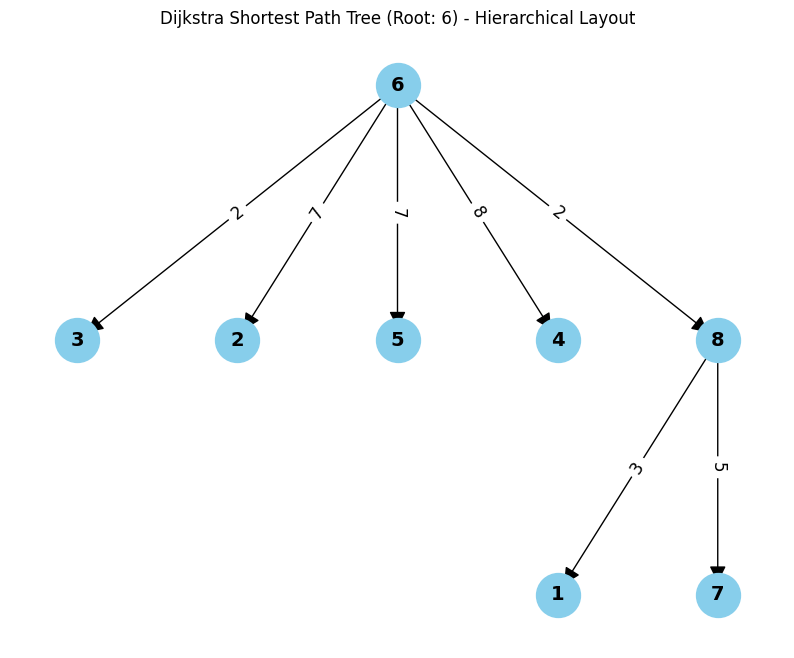

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a DiGraph (Directed Graph)
SPT = nx.DiGraph()

# Add edges based on the Shortest Path Tree (Root: 6) from the table
edges = [
    ('6', '3', {'weight': 2}),
    ('6', '2', {'weight': 7}),
    ('6', '5', {'weight': 7}),
    ('6', '4', {'weight': 8}),
    ('6', '8', {'weight': 2}),
    ('8', '1', {'weight': 3}), # Path 6->8->1
    ('8', '7', {'weight': 5})  # Path 6->8->7
]
SPT.add_edges_from(edges)

# 2. Visualization
plt.figure(figsize=(10, 8))

# Using pydot_layout for hierarchical arrangement
# Specify 'dot' (standard Graphviz layout for trees)
from networkx.drawing.nx_pydot import pydot_layout
pos = pydot_layout(SPT, prog='dot') # 'dot' makes a top-down structure

# Draw nodes and edges
nx.draw_networkx_nodes(SPT, pos, node_size=1000, node_color='skyblue')
nx.draw_networkx_edges(SPT, pos, edgelist=SPT.edges(), edge_color='black',
                       arrows=True, arrowsize=25)
nx.draw_networkx_labels(SPT, pos, font_size=14, font_family='sans-serif',
                        font_weight='bold')


# Draw edge weights (to confirm it's an SPT)
edge_labels = nx.get_edge_attributes(SPT, 'weight')
nx.draw_networkx_edge_labels(SPT, pos, edge_labels=edge_labels, font_size=12)

plt.title("Dijkstra Shortest Path Tree (Root: 6) - Hierarchical Layout")
plt.axis('off') # Turn off axes

plt.savefig("dijkstra.pdf", format="pdf", bbox_inches='tight')

plt.show()

# Bellmann-Ford algorithm

In [10]:
def bellman_ford(graph, start_node):
    # 1. Initialization: distances to all nodes = infinity, to start node = 0
    distances = {node: float('inf') for node in graph}
    distances[start_node] = 0

    # Number of vertices
    v_count = len(graph)

    # 2. Main loop: relax all edges (V - 1) times
    for _ in range(v_count - 1):
        for u in graph:
            for v, weight in graph[u].items():
                if distances[u] != float('inf') and distances[u] + weight < distances[v]:
                    distances[v] = distances[u] + weight

    # 3. Check for negative cycles
    # If after (V-1) iterations we can still improve a path, there is a negative cycle
    for u in graph:
        for v, weight in graph[u].items():
            if distances[u] != float('inf') and distances[u] + weight < distances[v]:
                print("Warning: The graph contains a negative cycle!")
                return None, None

    return distances

result = bellman_ford(graph, '6')

if result:
    print("Shortest distances from node 6:")
    for node, dist in sorted(result.items()):
        print(f"To node {node}: {dist}")

Shortest distances from node 6:
To node 1: 5
To node 2: 7
To node 3: 2
To node 4: 8
To node 5: 7
To node 6: 0
To node 7: 7
To node 8: 2


# 3. Floyd Warshall

In [11]:
import numpy as np

def floyd_warshall(graph):
    v_count = len(graph)
    # Initialize matrix D(0)
    # Use a very large number for infinity
    inf = float('inf')
    dist = np.array(graph, dtype=float)

    # Save the history of all matrices for reporting
    history = [dist.copy()]

    # Main Floyd-Warshall loop
    for k in range(v_count):
        for i in range(v_count):
            for j in range(v_count):
                if dist[i, j] > dist[i, k] + dist[k, j]:
                    dist[i, j] = dist[i, k] + dist[k, j]

        # Save the state of matrix D(k+1)
        history.append(dist.copy())

    return dist, history

# Example: Your graph (inf - no connection, 0 - diagonal)
inf = float('inf')
graph = [
    [0,   inf, inf, inf, 13,  9,   6,   3],
    [inf, 0,   6,   inf, inf, 7,   inf, 8],
    [inf, 6,   0,   9,   inf, 2,   inf, inf],
    [inf, inf, 9,   0,   18,  8,   inf, inf],
    [13,  inf, inf, 18,  0,   7,   4,   inf],
    [9,   7,   2,   8,   7,   0,   inf, 2],
    [6,   inf, inf, inf, 4,   inf, 0,   5],
    [3,   8,   inf, inf, inf, 2,   5,   0]
]

final_matrix, history = floyd_warshall(graph)

# Output the final matrix
print("Final matrix D(8):")
print(final_matrix)

# Output a specific step k (e.g., D(1))
print("\nMatrix D(1):")
print(history[8])

Final matrix D(8):
[[ 0. 11.  7. 13. 10.  5.  6.  3.]
 [11.  0.  6. 15. 14.  7. 13.  8.]
 [ 7.  6.  0.  9.  9.  2.  9.  4.]
 [13. 15.  9.  0. 15.  8. 15. 10.]
 [10. 14.  9. 15.  0.  7.  4.  9.]
 [ 5.  7.  2.  8.  7.  0.  7.  2.]
 [ 6. 13.  9. 15.  4.  7.  0.  5.]
 [ 3.  8.  4. 10.  9.  2.  5.  0.]]

Matrix D(1):
[[ 0. 11.  7. 13. 10.  5.  6.  3.]
 [11.  0.  6. 15. 14.  7. 13.  8.]
 [ 7.  6.  0.  9.  9.  2.  9.  4.]
 [13. 15.  9.  0. 15.  8. 15. 10.]
 [10. 14.  9. 15.  0.  7.  4.  9.]
 [ 5.  7.  2.  8.  7.  0.  7.  2.]
 [ 6. 13.  9. 15.  4.  7.  0.  5.]
 [ 3.  8.  4. 10.  9.  2.  5.  0.]]


In [12]:
import numpy as np

def floyd_warshall_path(graph):
    n = len(graph)
    dist = np.array(graph, dtype=float)
    # Predecessor matrix: next_node[i][j] stores the next vertex in the path from i to j
    next_node = np.full((n, n), -1, dtype=int)

    # Initialize predecessors
    for i in range(n):
        for j in range(n):
            if graph[i][j] != float('inf') and i != j:
                next_node[i][j] = j

    # Main loop
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i][j] > dist[i][k] + dist[k][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
                    next_node[i][j] = next_node[i][k]

    return dist, next_node

def get_path(i, j, next_node):
    if next_node[i][j] == -1:
        return []
    path = [i]
    while i != j:
        i = next_node[i][j]
        path.append(i)
    return path

# Your graph
inf = float('inf')
graph = [
    [0, inf, inf, inf, 13, 9, 6, 3],
    [inf, 0, 6, inf, inf, 7, inf, 8],
    [inf, 6, 0, 9, inf, 2, inf, inf],
    [inf, inf, 9, 0, 18, 8, inf, inf],
    [13, inf, inf, 18, 0, 7, 4, inf],
    [9, 7, 2, 8, 7, 0, inf, 2],
    [6, inf, inf, inf, 4, inf, 0, 5],
    [3, 8, inf, inf, inf, 2, 5, 0]
]

dist, next_node = floyd_warshall_path(graph)

# 1. Find the diameter
diameter = np.max(dist[dist != inf])
print(f"Graph diameter: {diameter}")

# 2. Find all pairs where the distance is equal to the diameter
print("Diametral pairs and their paths:")
for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        if dist[i][j] == diameter:
            path = get_path(i, j, next_node)
            # In the code, vertices are 0-7, convert to 1-8 for reporting
            readable_path = [node + 1 for node in path]
            print(f"Pair ({i+1}, {j+1}): Path {readable_path}")

Graph diameter: 15.0
Diametral pairs and their paths:
Pair (2, 4): Path [2, np.int64(3), np.int64(4)]
Pair (4, 5): Path [4, np.int64(6), np.int64(5)]
Pair (4, 7): Path [4, np.int64(6), np.int64(8), np.int64(7)]


In [14]:
import numpy as np

def floyd_warshall_with_p_history(graph_data):
    v_count = len(graph_data)
    inf = float('inf')

    # Konvertējam sākuma grafu par NumPy masīvu, lai izvairītos no indeksācijas kļūdām
    dist = np.array(graph_data, dtype=float)

    # Inicializācija P(0) matricai (priekšteču matrica)
    parent = np.zeros((v_count, v_count), dtype=int)
    for i in range(v_count):
        for j in range(v_count):
            if i == j:
                parent[i, j] = i + 1
            elif dist[i, j] != inf:
                parent[i, j] = i + 1
            else:
                parent[i, j] = 0

    # Vēstures saraksti
    d_history = [dist.copy()]
    p_history = [parent.copy()]

    # Algoritma galvenais cikls
    for k in range(v_count):
        for i in range(v_count):
            for j in range(v_count):
                if dist[i, k] + dist[k, j] < dist[i, j]:
                    dist[i, j] = dist[i, k] + dist[k, j]
                    # Atjaunojam priekšteci
                    parent[i, j] = parent[k, j]

        d_history.append(dist.copy())
        p_history.append(parent.copy())

    return d_history, p_history

def to_latex(matrix, name):
    """Funkcija, kas pārvērš matricu LaTeX kodā"""
    lines = [f"\\[ {name} = \\begin{{pmatrix}}"]
    for row in matrix:
        # Ja tie ir attālumi, aizvietojam inf ar \infty, citādi veseli skaitļi
        row_str = " & ".join(["\\infty" if x == float('inf') else str(int(x)) for x in row])
        lines.append(row_str + " \\\\")
    lines.append("\\end{pmatrix} \\]")
    return "\n".join(lines)

# Grafs (0 uz diagonāles, svars vai inf)
inf = float('inf')
graph = [
    [0,   inf, inf, inf, 13,  9,   6,   3],
    [inf, 0,   6,   inf, inf, 7,   inf, 8],
    [inf, 6,   0,   9,   inf, 2,   inf, inf],
    [inf, inf, 9,   0,   18,  8,   inf, inf],
    [13,  inf, inf, 18,  0,   7,   4,   inf],
    [9,   7,   2,   8,   7,   0,   inf, 2],
    [6,   inf, inf, inf, 4,   inf, 0,   5],
    [3,   8,   inf, inf, inf, 2,   5,   0]
]

d_hist, p_hist = floyd_warshall_with_p_history(graph)

# Piemērs: Izvadīt P(8) LaTeX formātā
print("Matrica P(8) LaTeX formātā:")
print(to_latex(d_hist[8], "P^{(8)}"))
print(to_latex(p_hist[8], "P^{(8)}"))
# Piemērs: Izvadīt D(8) LaTeX formātā
# print("\nMatrica D(8) LaTeX formātā:")
# print(to_latex(d_hist[8], "D^{(8)}"))

Matrica P(8) LaTeX formātā:
\[ P^{(8)} = \begin{pmatrix}
0 & 11 & 7 & 13 & 10 & 5 & 6 & 3 \\
11 & 0 & 6 & 15 & 14 & 7 & 13 & 8 \\
7 & 6 & 0 & 9 & 9 & 2 & 9 & 4 \\
13 & 15 & 9 & 0 & 15 & 8 & 15 & 10 \\
10 & 14 & 9 & 15 & 0 & 7 & 4 & 9 \\
5 & 7 & 2 & 8 & 7 & 0 & 7 & 2 \\
6 & 13 & 9 & 15 & 4 & 7 & 0 & 5 \\
3 & 8 & 4 & 10 & 9 & 2 & 5 & 0 \\
\end{pmatrix} \]
\[ P^{(8)} = \begin{pmatrix}
1 & 8 & 6 & 6 & 7 & 8 & 1 & 1 \\
8 & 2 & 2 & 3 & 6 & 2 & 8 & 2 \\
8 & 3 & 3 & 3 & 6 & 3 & 8 & 6 \\
8 & 3 & 4 & 4 & 6 & 4 & 8 & 6 \\
7 & 6 & 6 & 6 & 5 & 5 & 5 & 6 \\
8 & 6 & 6 & 6 & 6 & 6 & 8 & 6 \\
7 & 8 & 6 & 6 & 7 & 8 & 7 & 7 \\
8 & 8 & 6 & 6 & 6 & 8 & 8 & 8 \\
\end{pmatrix} \]


# using networkx

In [8]:
import networkx as nx

G = nx.Graph()

graph = {
    '1': {'5': 13, '6': 9, '7': 6, '8': 3},
    '2': {'3': 6, '6': 7, '8': 8},
    '3': {'2': 6, '4': 9, '6': 2},
    '4': {'3': 9, '5': 18, '6': 8},
    '5': {'1': 13, '4': 18, '6': 7, '7': 4},
    '6': {'1': 9, '2': 7, '3': 2, '4': 8, '5': 7, '8': 2},
    '7': {'1': 6, '5': 4, '8': 5},
    '8': {'1': 3, '2': 8, '6': 2, '7': 5}
}

edges_to_add = []
for u, neighbors in graph.items():
    for v, weight in neighbors.items():
        edges_to_add.append((u, v, weight))
G.add_weighted_edges_from(edges_to_add)

source_node = '6'

all_lengths = nx.single_source_dijkstra_path_length(G,
                                                    source=source_node,
                                                    weight='weight')
print(f"\nDeikstras algoritms, visas distances no virsotnes {source_node}:")
for node in sorted(all_lengths.keys()):
    print(f"Virsotne {node}: {all_lengths[node]}")


Deikstras algoritms, visas distances no virsotnes 6:
Virsotne 1: 5
Virsotne 2: 7
Virsotne 3: 2
Virsotne 4: 8
Virsotne 5: 7
Virsotne 6: 0
Virsotne 7: 7
Virsotne 8: 2


In [6]:
import networkx as nx

# Your graph (G is already created above)
# Solution via a specific method:
lengths = nx.bellman_ford_path_length(G, source='6', target='4', weight='weight')
path = nx.bellman_ford_path(G, source='6', target='4', weight='weight')

all_lengths_bell = nx.single_source_bellman_ford_path_length(G,
                                                    source=source_node,
                                                    weight='weight')

print("\nBelmana-Forda algoritms, visas distances no virsotnes 6:")
for node in sorted(all_lengths_bell.keys()):
    print(f"Virsotne {node}: {all_lengths_bell[node]}")

print(f"Bellman-Ford length: {lengths}")


Belmana-Forda algoritms, visas distances no virsotnes 6:
Virsotne 1: 5
Virsotne 2: 7
Virsotne 3: 2
Virsotne 4: 8
Virsotne 5: 7
Virsotne 6: 0
Virsotne 7: 7
Virsotne 8: 2
Bellman-Ford length: 8


In [11]:
import networkx as nx
import pandas as pd

# 2. Flouda-Voršala algoritms
# Atgriež vārdnīcu no vārdnīcām: distance[avots][mērķis]
dist_dict = nx.floyd_warshall(G, weight='weight')

# 3. Pārveidojam par Pandas DataFrame vizuālai skaidrībai (kā jūsu tabula D8)
nodes = sorted(G.nodes(), key=int)
dist_matrix = pd.DataFrame(dist_dict, index=nodes, columns=nodes)

print("--- Attālumu matrica D(8) ---")
print(dist_matrix)

# 4. Aprēķinām grafa raksturlielumus
eccentricities = nx.eccentricity(G, sp=dist_dict)
radius = nx.radius(G, e=eccentricities)
diameter = nx.diameter(G, e=eccentricities)
center = nx.center(G, e=eccentricities)
periphery = nx.periphery(G, e=eccentricities)

print("\n--- Grafa raksturlielumi ---")
print(f"Ekscentritātes: {eccentricities}")
print(f"Rādiuss (R): {radius}")
print(f"Diametrs (D): {diameter}")
print(f"Centrs (virsotnes): {center}")
print(f"Perifērijas virsotnes: {periphery}")

# 5. Diametrālās ķēdes atrašana
# Meklējam jebkuru virsotņu pāri, kura attālums ir vienāds ar diametru
for u in nodes:
    for v in nodes:
        if dist_dict[u][v] == diameter:
            path = nx.shortest_path(G, source=u, target=v, weight='weight')
            print(f"Diametrālā ķēde ({u} -> {v}): {path}")
            #break
    #else: continue
    #break

--- Attālumu matrica D(8) ---
    1   2  3   4   5  6   7   8
1   0  11  7  13  10  5   6   3
2  11   0  6  15  14  7  13   8
3   7   6  0   9   9  2   9   4
4  13  15  9   0  15  8  15  10
5  10  14  9  15   0  7   4   9
6   5   7  2   8   7  0   7   2
7   6  13  9  15   4  7   0   5
8   3   8  4  10   9  2   5   0

--- Grafa raksturlielumi ---
Ekscentritātes: {'1': 13, '5': 15, '6': 8, '7': 15, '8': 10, '2': 15, '3': 9, '4': 15}
Rādiuss (R): 8
Diametrs (D): 15
Centrs (virsotnes): ['6']
Perifērijas virsotnes: ['5', '7', '2', '4']
Diametrālā ķēde (2 -> 4): ['2', '3', '4']
Diametrālā ķēde (4 -> 2): ['4', '3', '2']
Diametrālā ķēde (4 -> 5): ['4', '6', '5']
Diametrālā ķēde (4 -> 7): ['4', '6', '8', '7']
Diametrālā ķēde (5 -> 4): ['5', '6', '4']
Diametrālā ķēde (7 -> 4): ['7', '8', '6', '4']
